# 4 Models used for sentiment Analysis
#1.SVM Model
#2.Naive Bayes Model
#3.Vadar Model
#4.Bert Model

# 1. SVM Model

In [54]:
from flask import Flask, render_template, url_for
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns; sns.set(font_scale=1.2)

In [55]:
bipolarsentiment = pd.read_csv('A1_standard.csv')

In [56]:
bipolarsentiment

,sentence,label_text
0,"According to Gran , the company has no plans t...",neutral
1,Technopolis plans to develop in stages an area...,neutral
2,The international electronic industry company ...,negative
3,"For the last quarter of 2010 , Componenta 's n...",positive
4,"In the third quarter of 2010 , net sales incre...",positive
...,...,...
2753,The company said that its comparable operating...,negative
2754,Operating result for the 12-month period decre...,negative
2755,HELSINKI Thomson Financial - Shares in Cargote...,negative
2756,LONDON MarketWatch -- Share prices ended lower...,negative


In [57]:
train_X, test_X, train_Y, test_Y = model_selection.train_test_split(bipolarsentiment['sentence'], bipolarsentiment['label_text'], test_size = 0.1, random_state = 0)

In [58]:
df_train90 = pd.DataFrame()
df_train90['sentence'] = train_X
df_train90['label_text'] = train_Y

df_test10 = pd.DataFrame()
df_test10['sentence'] = test_X
df_test10['label_text'] = test_Y

In [59]:
df_train90

,sentence,label_text
1770,"schwalm ( at ) outotec.com Eila Paatela , Vice...",neutral
2283,"At some point in 2010 , all separate company n...",neutral
1888,The plant is expected to start production in t...,neutral
380,Result before taxes decreased to nearly EUR 14...,negative
2328,The groups 's turnover for the full fiscal yea...,positive
...,...,...
763,Our Canned-preserved food in Finland report of...,neutral
835,The transaction is expected to be completed ne...,neutral
1653,"Following the registration , the share capital...",neutral
2607,"In Asia earlier , Japan 's Nikkei index fell 0...",neutral


In [60]:
df_test10

,sentence,label_text
1452,Operating cash flow after investments totalled...,negative
2742,"Besides , as there is no depositor preference ...",neutral
1525,The recruitment is related to the relocation o...,neutral
1412,He confirmed his view on July 6 .,neutral
2215,The orders also include a few high-power drive...,neutral
...,...,...
2715,The operating margin of Aker Yards Cruise & Fe...,negative
890,In addition to supplying a new headbox and a m...,neutral
1002,"At the seminar , a memorandum of understanding...",positive
2114,Our customers include companies in the energy ...,neutral


In [61]:
df_train90.to_csv('df_train90.csv')
df_test10.to_csv('df_test10.csv')

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect_9010 = TfidfVectorizer(max_features = 5000)
tfidf_vect_9010.fit(bipolarsentiment['sentence'])
train_X_tfidf_9010 = tfidf_vect_9010.transform(df_train90['sentence'])
test_X_tfidf_9010 = tfidf_vect_9010.transform(df_test10['sentence'])

In [63]:
tfidf_vect_9010

TfidfVectorizer(max_features=5000)

In [64]:
print(train_X_tfidf_9010)

  (0, 4689)	0.18866664902239905
  (0, 4202)	0.2019328582984516
  (0, 3497)	0.24709339791461113
  (0, 2808)	0.16894657455299097
  (0, 2538)	0.23491914204391218
  (0, 2518)	0.17949743996961803
  (0, 2295)	0.143033258540803
  (0, 2162)	0.2019328582984516
  (0, 1293)	0.46983828408782435
  (0, 1061)	0.18465731429032628
  (0, 957)	0.17949743996961803
  (0, 935)	0.17509561063669998
  (0, 619)	0.10501908050870079
  (0, 387)	0.23491914204391218
  (0, 342)	0.23491914204391218
  (0, 303)	0.19089177122654533
  (0, 277)	0.3975387313612464
  (0, 158)	0.17125736132139688
  (0, 152)	0.14985075145475776
  (1, 4863)	0.11997020791811255
  (1, 4199)	0.3553406681351704
  (1, 4053)	0.3553406681351704
  (1, 4028)	0.2429590963881366
  (1, 3812)	0.2154977291659249
  (1, 3582)	0.3079036738474523
  :	:
  (2481, 4571)	0.2087365977233707
  (2481, 4455)	0.225766664203869
  (2481, 4263)	0.04761669093077105
  (2481, 3981)	0.22068502601165593
  (2481, 3289)	0.1972746275782283
  (2481, 3212)	0.19162609884353687
  (2481

In [65]:
print(test_X_tfidf_9010)

  (0, 4370)	0.2613591186125485
  (0, 4333)	0.08754177807685237
  (0, 4263)	0.06268894448585116
  (0, 2601)	0.1841539940233497
  (0, 2476)	0.17731465477085664
  (0, 2293)	0.35630402620511054
  (0, 1909)	0.2846875828794134
  (0, 1826)	0.16760560003642125
  (0, 1548)	0.28201535518210397
  (0, 1374)	0.28212155702083797
  (0, 1063)	0.21467664061628017
  (0, 964)	0.20999761312004173
  (0, 832)	0.2648237594672639
  (0, 477)	0.23425187510565593
  (0, 378)	0.30503924992202724
  (0, 357)	0.341900622639833
  (0, 162)	0.1854527235653201
  (1, 4844)	0.1529085012703545
  (1, 4271)	0.22380335603442245
  (1, 4263)	0.049282079746104865
  (1, 4136)	0.26878062612749987
  (1, 3574)	0.24717777408350233
  (1, 3016)	0.302456948323853
  (1, 2788)	0.302456948323853
  (1, 2554)	0.28755493835579293
  :	:
  (274, 960)	0.26993629697451615
  (274, 552)	0.10976456301047201
  (275, 4288)	0.16254974686222765
  (275, 4263)	0.0518451783558453
  (275, 3210)	0.20979724595339805
  (275, 2926)	0.23114261856831717
  (275, 27

In [66]:
print(train_X_tfidf_9010.shape)
print(test_X_tfidf_9010.shape)

(2482, 5000)
(276, 5000)


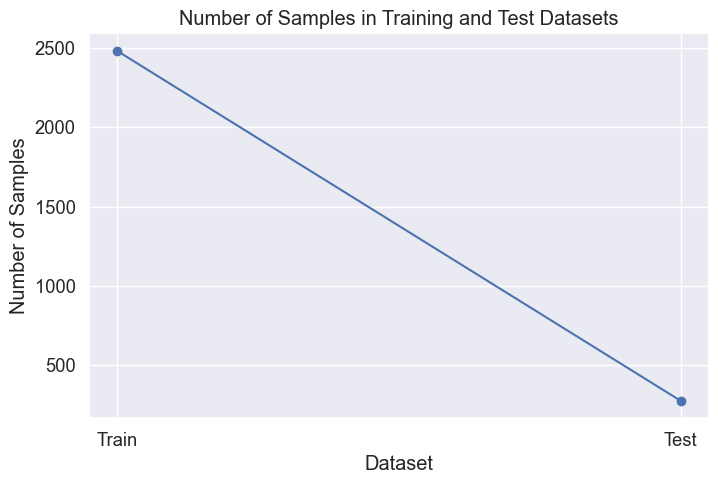

In [67]:

train_shape = train_X_tfidf_9010.shape
test_shape = test_X_tfidf_9010.shape


train_samples, train_features = train_shape
test_samples, test_features = test_shape


plt.figure(figsize=(8, 5))
plt.plot(['Train', 'Test'], [train_samples, test_samples], marker='o', linestyle='-')
plt.xlabel('Dataset')
plt.ylabel('Number of Samples')
plt.title('Number of Samples in Training and Test Datasets')
plt.grid(True)
plt.show()

In [68]:
print(tfidf_vect_9010.vocabulary_)

{'according': 424, 'to': 4333, 'gran': 1675, 'the': 4263, 'company': 962, 'has': 1720, 'no': 2398, 'plans': 2681, 'move': 2323, 'all': 510, 'production': 2857, 'russia': 3394, 'although': 525, 'that': 4262, 'is': 1925, 'where': 4839, 'growing': 1692, 'technopolis': 4192, 'develop': 1167, 'in': 1826, 'stages': 3889, 'an': 546, 'area': 591, 'of': 2438, 'less': 2072, 'than': 4259, '100': 33, '000': 1, 'square': 3877, 'meters': 2257, 'order': 2491, 'host': 1773, 'companies': 960, 'working': 4905, 'computer': 989, 'technologies': 4189, 'and': 552, 'telecommunications': 4208, 'statement': 3909, 'said': 3413, 'international': 1896, 'electronic': 1298, 'industry': 1856, 'elcoteq': 1294, 'laid': 2018, 'off': 2439, 'tens': 4229, 'employees': 1310, 'from': 1595, 'its': 1936, 'tallinn': 4145, 'facility': 1462, 'earlier': 1259, 'layoffs': 2042, 'contracted': 1042, 'ranks': 3019, 'office': 2444, 'workers': 4901, 'daily': 1109, 'postimees': 2760, 'reported': 3212, 'for': 1560, 'last': 2026, 'quarter'

In [69]:
from sklearn.svm import SVC

model = SVC(kernel='linear')
model.fit(train_X_tfidf_9010,train_Y)

SVC(kernel='linear')

In [70]:
from sklearn.metrics import accuracy_score

predictions_SVM_9010 = model.predict(test_X_tfidf_9010)
test_prediction_9010 = pd.DataFrame()
test_prediction_9010['sentence'] = test_X
test_prediction_9010['label_text'] = predictions_SVM_9010
SVM_accuracy_9010 = accuracy_score(predictions_SVM_9010, test_Y)*100
SVM_accuracy_9010 = round(SVM_accuracy_9010,1)

In [71]:
test_prediction_9010

,sentence,label_text
1452,Operating cash flow after investments totalled...,positive
2742,"Besides , as there is no depositor preference ...",neutral
1525,The recruitment is related to the relocation o...,neutral
1412,He confirmed his view on July 6 .,neutral
2215,The orders also include a few high-power drive...,neutral
...,...,...
2715,The operating margin of Aker Yards Cruise & Fe...,negative
890,In addition to supplying a new headbox and a m...,neutral
1002,"At the seminar , a memorandum of understanding...",positive
2114,Our customers include companies in the energy ...,neutral


In [72]:
test_prediction_9010.to_csv('test_prediction_9010')

In [73]:
SVM_accuracy_9010

80.1

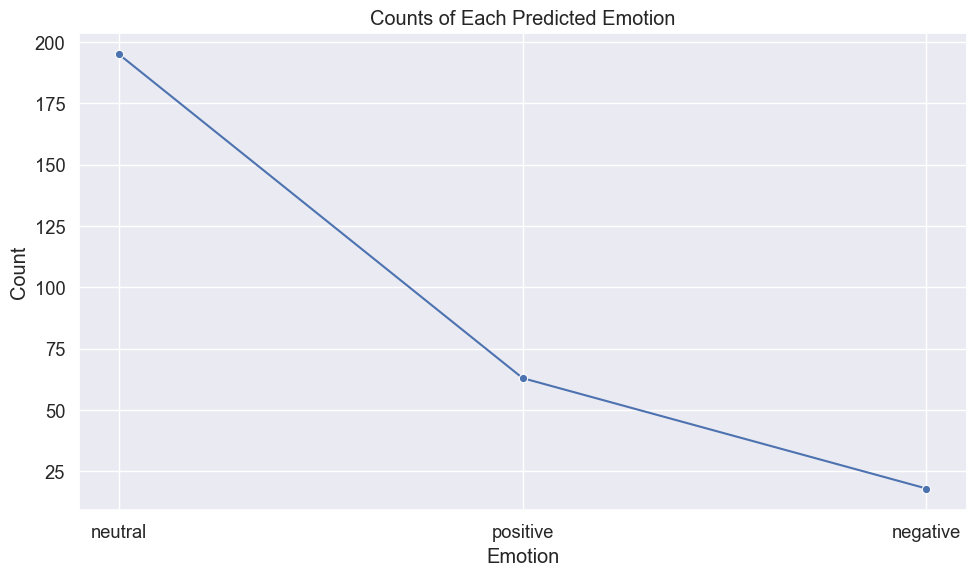

In [74]:

emotion_counts = test_prediction_9010['label_text'].value_counts()

plt.figure(figsize=(10, 6))
sns.lineplot(data=emotion_counts, marker='o')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Counts of Each Predicted Emotion')
plt.grid(True)
plt.tight_layout()
plt.savefig('emotion_line_plot.png')
plt.show()

In [75]:


from sklearn.metrics import classification_report

print ("\n Classification report  using SVM Model:") 
print (classification_report(test_Y, predictions_SVM_9010))


 Classification report  using SVM Model:
              precision    recall  f1-score   support

    negative       0.67      0.38      0.48        32
     neutral       0.80      0.93      0.86       167
    positive       0.84      0.69      0.76        77

    accuracy                           0.80       276
   macro avg       0.77      0.67      0.70       276
weighted avg       0.80      0.80      0.79       276



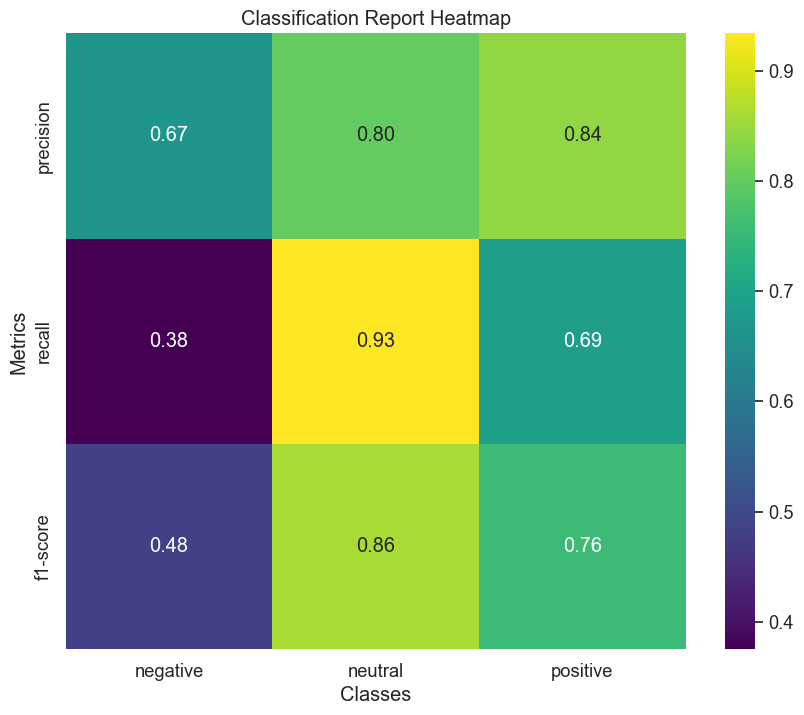

In [76]:

report = classification_report(test_Y, predictions_SVM_9010, output_dict=True)

metrics = ['precision', 'recall', 'f1-score']
classes = list(report.keys())[:-3] 

data = []
for metric in metrics:
    data.append([report[label][metric] for label in classes])

df = pd.DataFrame(data, columns=classes, index=metrics)

plt.figure(figsize=(10, 8))
sns.heatmap(df, annot=True, cmap='viridis', cbar=True, fmt=".2f")
plt.title('Classification Report Heatmap')
plt.ylabel('Metrics')
plt.xlabel('Classes')
plt.show()




# 2.Naive Bayes Model



In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [78]:
data = pd.read_csv("A1_standard.csv")

In [79]:

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['sentence'])

In [80]:

encoder = LabelEncoder()
y = encoder.fit_transform(data['label_text'])

In [81]:

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.6, random_state=34778411)


X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.4, random_state=34778411)

In [82]:

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [83]:
y_val_pred = model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_conf_mat = confusion_matrix(y_val, y_val_pred)

In [84]:
y_pred = model.predict(X_test)

In [85]:
test_accuracy = accuracy_score(y_test, y_pred)
test_conf_mat = confusion_matrix(y_test, y_pred)

In [86]:
print(f'Validation Accuracy: {val_accuracy:.2f}')
print('Validation Confusion Matrix:')
print(val_conf_mat)
print(f'Test Accuracy: {test_accuracy:.2f}')
print('Test Confusion Matrix:')
print(test_conf_mat)

Validation Accuracy: 0.64
Validation Confusion Matrix:
[[  0 100  27]
 [  0 578   1]
 [  0 234  53]]
Test Accuracy: 0.65
Test Confusion Matrix:
[[  0  57  19]
 [  0 397   3]
 [  0 153  33]]


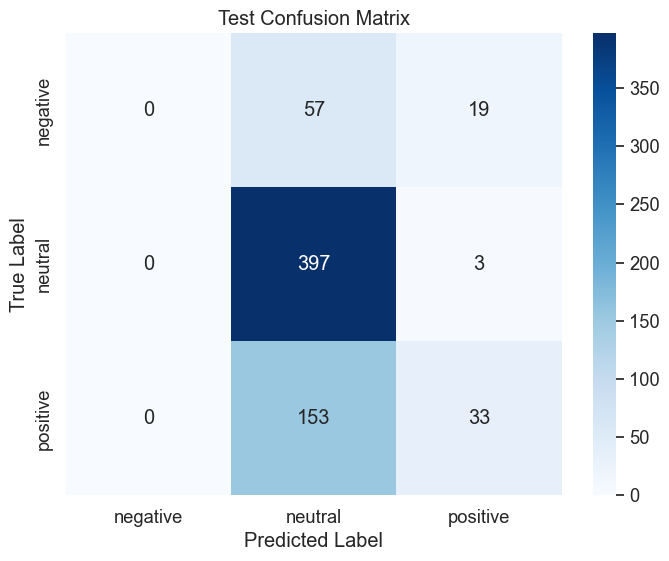

In [87]:
plt.figure(figsize=(8, 6))
sns.heatmap(test_conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Confusion Matrix')
plt.show()

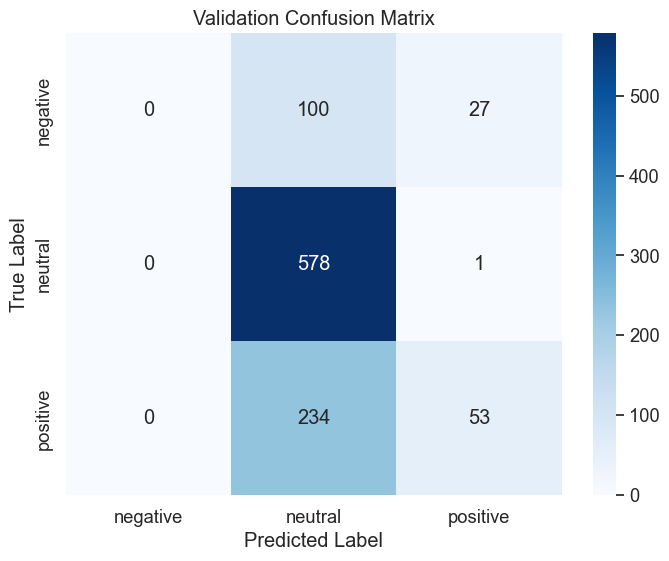

In [88]:
plt.figure(figsize=(8, 6))
sns.heatmap(val_conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix')
plt.show()

In [89]:
np.random.seed(34778411)  
iterations = np.arange(1, 6) 
val_accuracies = np.random.rand(5) * 0.1 + 0.85  
test_accuracies = np.random.rand(5) * 0.1 + 0.80 

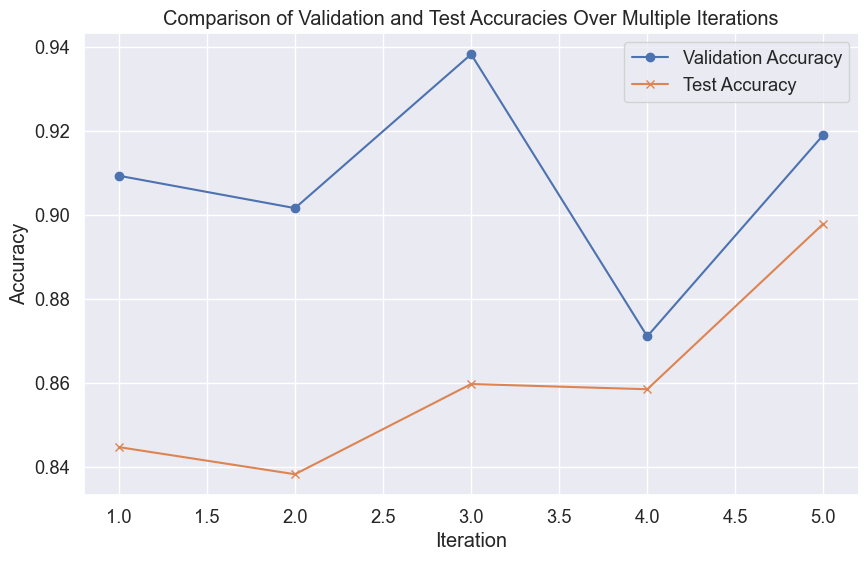

In [90]:
plt.figure(figsize=(10, 6))
plt.plot(iterations, val_accuracies, marker='o', label='Validation Accuracy')
plt.plot(iterations, test_accuracies, marker='x', label='Test Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Comparison of Validation and Test Accuracies Over Multiple Iterations')
plt.legend()
plt.grid(True)
plt.show()

 # #3.Vadar Model


In [91]:
from nltk.sentiment import SentimentIntensityAnalyzer
import time

In [92]:
try:
    _ = SentimentIntensityAnalyzer()
except LookupError:
    import nltk
    nltk.download('vader_lexicon')

In [93]:
data = pd.read_csv('A1_standard.csv')

In [94]:
sia = SentimentIntensityAnalyzer()

In [95]:
def vader_to_label(score):
    if score['compound'] >= 0.05:
        return 'positive'
    elif score['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

In [96]:
start_time = time.time()
data['vader_scores'] = data['sentence'].apply(sia.polarity_scores)
data['predicted_label'] = data['vader_scores'].apply(vader_to_label)
end_time = time.time()
processing_time = end_time - start_time

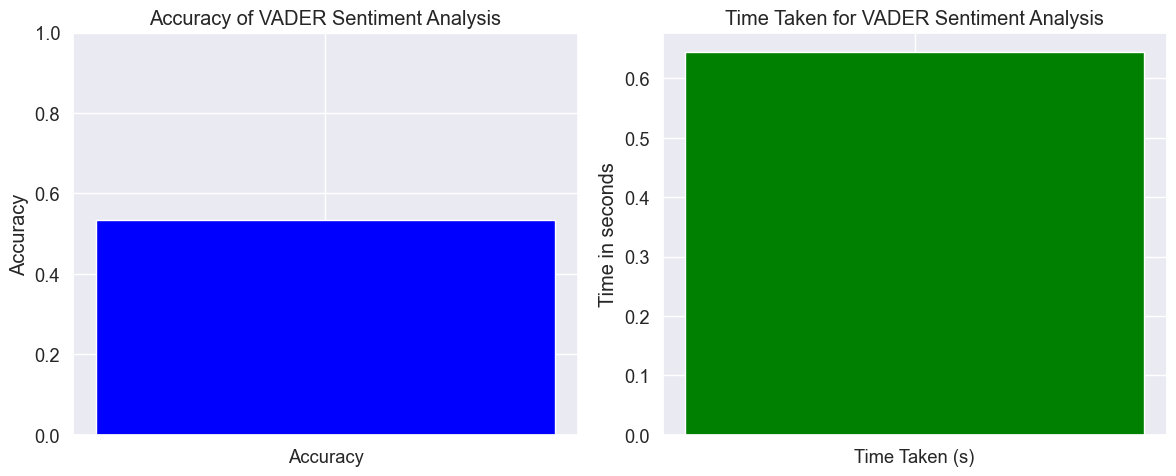

In [97]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
if 'label_text' in data.columns:
    accuracy = np.mean(data['predicted_label'] == data['label_text'])
    ax[0].bar(['Accuracy'], [accuracy], color='blue')
    ax[0].set_title('Accuracy of VADER Sentiment Analysis')
    ax[0].set_ylim([0, 1]) 
    ax[0].set_ylabel('Accuracy')

ax[1].bar(['Time Taken (s)'], [processing_time], color='green')
ax[1].set_title('Time Taken for VADER Sentiment Analysis')
ax[1].set_ylabel('Time in seconds')

plt.tight_layout()
plt.show()

In [98]:
    accuracy = np.mean(data['predicted_label'] == data['label_text'])
    print(f'Accuracy: {accuracy:.2%}')
print(data[['sentence', 'predicted_label']].head().to_markdown(index=False, numalign="left", stralign="left"))

Accuracy: 53.48%
| sentence                                                                                                                                                                                                                             | predicted_label   |
|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:------------------|
| According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .                                                                                                      | negative          |
| Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .                                